# Analise de Churn - Plataforma de Streaming

## Objetivo do Projeto

O objetivo desta análise é identificar possíveis padrões e fatores relacionados ao cancelamento de assinaturas (*churn*) em uma plataforma de streaming.

Durante o projeto serão realizadas etapas de:
- compreensão dos dados;
- limpeza e tratamento;
- tradução e padronização das informações;
- análise exploratória;
- visualização de dados;
- interpretação dos principais insights encontrados.

---

# Importação das Bibliotecas

As bibliotecas utilizadas neste projeto serão responsáveis pela manipulação, tratamento e visualização dos dados.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

---

# Leitura do Dataset

Nesta etapa será realizado o carregamento do dataset e uma análise inicial da estrutura dos dados.

In [2]:
df = pd.read_csv('./data/netflix_customer_churn.csv')

pd.options.display.float_format = '{:.2f}'.format

---

# Entendimento Inicial dos Dados

Aqui serão verificadas informações importantes do dataset, como:
- quantidade de linhas e colunas;
- tipos de dados;
- valores nulos;
- estatísticas descritivas;
- possíveis inconsistências.

In [3]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [4]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui 5000 linhas e 14 colunas.


In [5]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='object')

## Descrição das Colunas

| Coluna | Descrição |
|---|---|
| `customer_id` | Identificador único de cada cliente da plataforma. |
| `age` | Idade do cliente. |
| `gender` | Gênero do cliente. |
| `subscription_type` | Tipo de assinatura contratada pelo usuário. |
| `watch_hours` | Quantidade total de horas assistidas pelo usuário na plataforma. |
| `last_login_days` | Quantidade de dias desde o último acesso do usuário. |
| `region` | Região onde o usuário está localizado. |
| `device` | Dispositivo mais utilizado para acessar a plataforma. |
| `monthly_fee` | Valor mensal pago pela assinatura. |
| `churned` | Indica se o cliente cancelou ou não a assinatura. |
| `payment_method` | Método de pagamento utilizado pelo cliente. |
| `number_of_profiles` | Quantidade de perfis existentes na conta. |
| `avg_watch_time_per_day` | Percentual médio diário de tempo consumido na plataforma. |
| `favorite_genre` | Gênero de conteúdo mais assistido pelo usuário. |

## Separação das Colunas Numéricas e Categóricas

Para facilitar a análise exploratória dos dados, as colunas do dataset foram separadas entre variáveis numéricas e categóricas.

Essa divisão permite aplicar métodos e visualizações mais adequados para cada tipo de dado, tornando a análise mais organizada e eficiente.

- Variáveis numéricas serão utilizadas principalmente para análises estatísticas e distribuição dos dados.
- Variáveis categóricas serão utilizadas para análises de frequência, comparação entre categorias e relação com o churn.

In [6]:
colunas_numericas = [
    "age",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]

colunas_categoricas = [
    "gender",
    "subscription_type",
    "region",
    "device",
    "payment_method",
    "favorite_genre",
    "churned"
]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [8]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,43.85,11.65,30.09,13.68,0.50,3.02,0.87
std,15.50,12.01,17.54,3.69,0.50,1.42,2.62
min,18.00,0.01,0.00,8.99,0.00,1.00,0.00
25%,30.00,3.34,15.00,8.99,0.00,2.00,0.11
50%,44.00,8.00,30.00,13.99,1.00,3.00,0.29
75%,58.00,16.03,45.00,17.99,1.00,4.00,0.72
max,70.00,110.40,60.00,17.99,1.00,5.00,98.42


In [9]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for coluna in colunas_categoricas:
    print(f"\n📌", end=" ")
    print(df[coluna].value_counts())


📌 gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

📌 subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

📌 region
South America    873
Europe           867
North America    851
Asia             841
Africa           803
Oceania          765
Name: count, dtype: int64

📌 device
Tablet     1048
Laptop     1006
Mobile     1004
TV          993
Desktop     949
Name: count, dtype: int64

📌 payment_method
Debit Card     1030
PayPal         1026
Crypto          995
Gift Card       976
Credit Card     973
Name: count, dtype: int64

📌 favorite_genre
Drama          731
Documentary    729
Romance        725
Sci-Fi         720
Horror         713
Action         697
Comedy         685
Name: count, dtype: int64

📌 churned
1    2515
0    2485
Name: count, dtype: int64


---

# Limpeza e Tratamento dos Dados

Após a análise inicial do dataset, foi possível observar que não existem valores ausentes, registros duplicados e nem valores despadronizados relevantes que necessitem tratamento.

Dessa forma, esta etapa será focada em:
- análise de possíveis outliers;
- tradução das colunas e categorias;
- organização dos dados para facilitar a análise exploratória.

In [12]:
df = df[df["age"] >= 18]

Após ver que não é possivel um menor de 18 ser o titular da conta, foi decidido remover os registros de clientes com idade inferior a 18 anos para garantir a consistência dos dados.

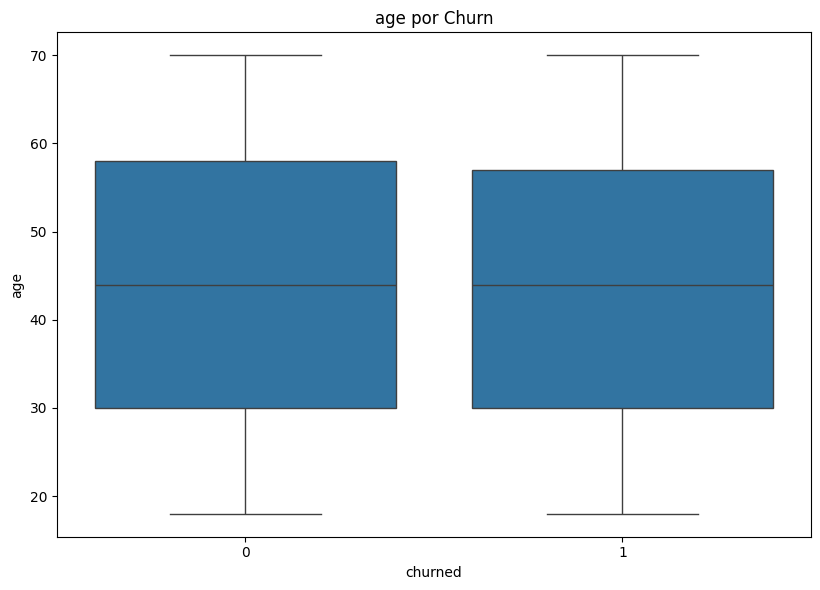

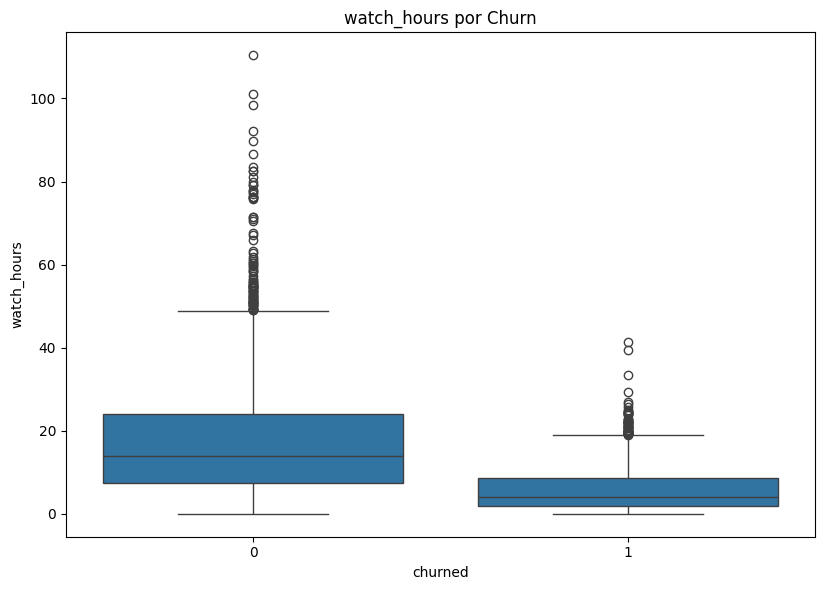

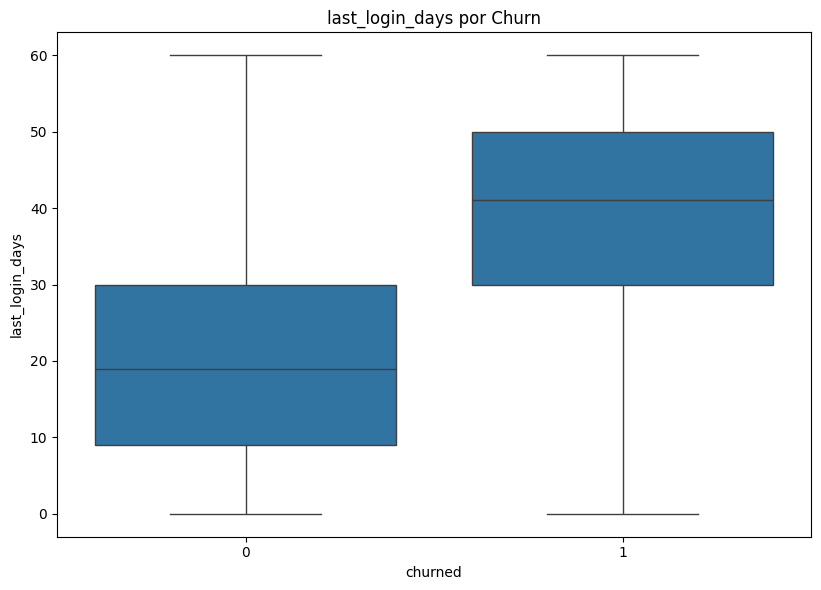

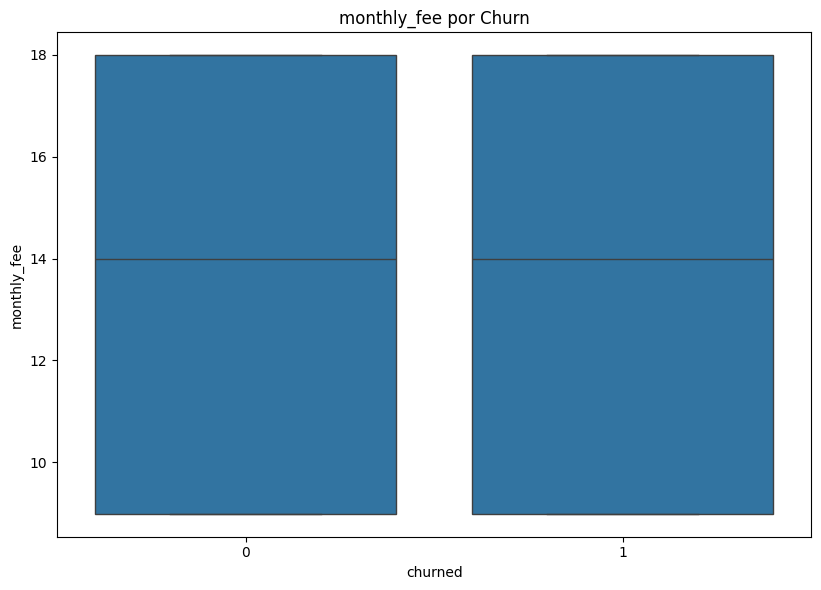

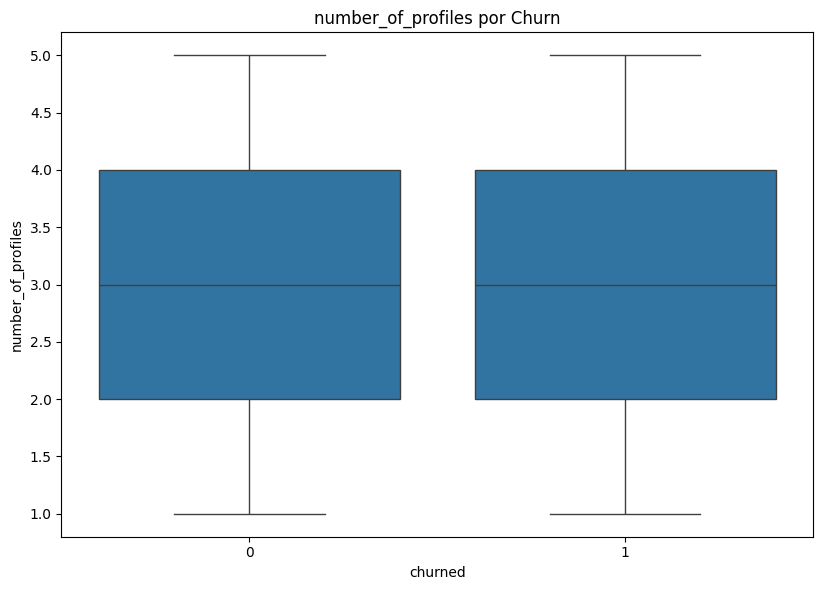

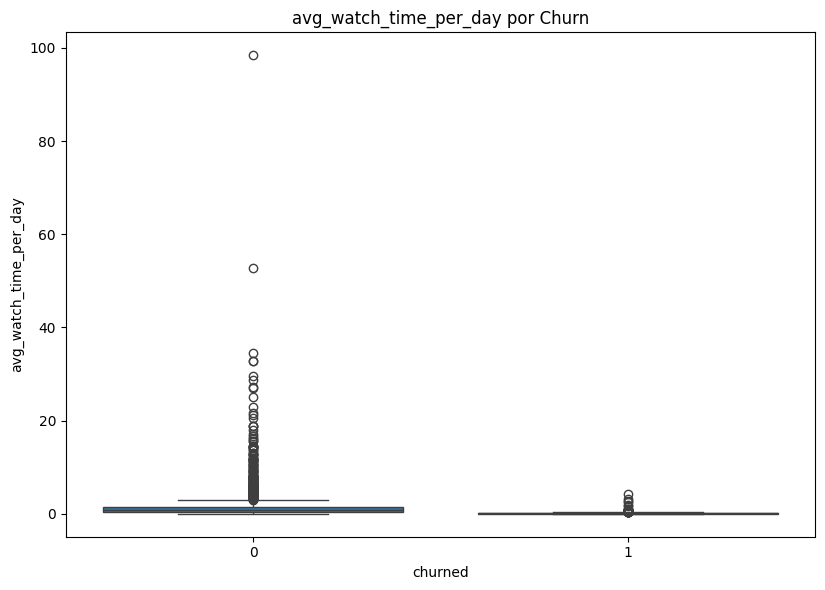

In [13]:
for coluna in colunas_numericas:
    
    plt.figure(figsize=(16,6))
    
    # Gráfico com churn
    plt.subplot(1, 2, 2)
    
    sns.boxplot(
        data=df,
        x="churned",
        y=coluna
    )
    
    plt.title(f"{coluna} por Churn")
    
    
    plt.tight_layout()
    plt.show()

### Análise dos Outliers

Durante a análise dos boxplots, foram identificados alguns valores considerados outliers em determinadas variáveis numéricas.

Entretanto, optou-se por não realizar a remoção desses valores, pois eles podem representar comportamentos reais dos usuários da plataforma.

No contexto de serviços de streaming, contas podem possuir múltiplos perfis ativos simultaneamente, o que pode gerar valores elevados de consumo diário. Além disso, existem usuários com padrões de uso intensivo, assistindo conteúdos por várias horas ao longo do dia.

Dessa forma, a remoção desses dados poderia eliminar informações relevantes sobre o comportamento real dos clientes e impactar negativamente a análise do churn.



## Tradução e Padronização dos Dados

Com o objetivo de facilitar a interpretação e visualização das informações, foi realizada a tradução dos nomes das colunas e de algumas categorias do dataset para português.

Além da tradução, também foi realizada a padronização de valores categóricos e monetários, tornando os dados mais organizados e compreensíveis durante a análise exploratória.

Essas alterações contribuem para uma leitura mais clara dos gráficos, tabelas e insights obtidos ao longo do projeto.

In [14]:
tradução_colunas = {
    "customer_id": "id_cliente",
    "age": "idade",
    "gender": "genero",
    "subscription_type": "tipo_assinatura",
    "watch_hours": "horas_assistidas",
    "last_login_days": "ultimo_dia_logado",
    "region": "regiao",
    "device": "dispositivo",
    "monthly_fee": "pagamento_mensal",
    "churned": "churn",
    "payment_method": "metodo_pagamento",
    "number_of_profiles": "quantidade_perfis",
    "avg_watch_time_per_day": "porcentagem_assistida_por_dia",
    "favorite_genre": "genero_favorito"
}

df.rename(columns=tradução_colunas, inplace=True)

df["tipo_assinatura"] = df["tipo_assinatura"].map({
    "Basic": "Padrão com anúncios",
    "Standard": "Padrão",
    "Premium": "Premium"
})

df["metodo_pagamento"] = df["metodo_pagamento"].map({
    "Credit Card": "Cartão de Crédito",
    "Debit Card": "Cartão de Débito",
    "Crypto": "Criptomoeda",
    "PayPal": "PayPal",
    "Gift Card": "Cartão Presente"
})

df["genero"] = df["genero"].map({
    "Male": "Masculino",
    "Female": "Feminino",
    "Other": "Outro"
})

df["pagamento_mensal"] = df["pagamento_mensal"].map({
    8.99: 20.90,
    13.99: 44.90,
    17.99: 59.90
})

df["genero_favorito"] = df["genero_favorito"].map({
    "Documentary": "Documentário",
    "Action": "Ação",
    "Comedy": "Comédia",
    "Horror": "Terror",
    "Romance": "Romance",
    "Sci-Fi": "Ficção Científica",
    "Drama": "Drama",
})

df["regiao"] = df["regiao"].map({
    "North America": "América do Norte",
    "Europe": "Europa",
    "Asia": "Ásia",
    "South America": "América do Sul",
    "Africa": "África",
    "Oceania": "Oceania"
})

df["dispositivo"] = df["dispositivo"].map({
    "Mobile": "Celular",
    "Tablet": "Tablet",
    "Desktop": "Computador",
    "TV": "TV",
    "Laptop": "Notebook"
})

In [15]:
df.head()

,id_cliente,idade,genero,tipo_assinatura,horas_assistidas,ultimo_dia_logado,regiao,dispositivo,pagamento_mensal,churn,metodo_pagamento,quantidade_perfis,porcentagem_assistida_por_dia,genero_favorito
0,a9b75100-82a8-427a-a208-72f24052884a,51,Outro,Padrão com anúncios,14.73,29,África,TV,20.90,1,Cartão Presente,1,0.49,Ação
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Outro,Padrão,0.70,19,Europa,Celular,44.90,1,Cartão Presente,5,0.03,Ficção Científica
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Feminino,Padrão,16.32,10,Ásia,TV,44.90,0,Criptomoeda,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Outro,Premium,4.51,12,Oceania,TV,59.90,1,Criptomoeda,2,0.35,Terror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Outro,Padrão,1.89,13,África,Celular,44.90,1,Criptomoeda,2,0.13,Ação


In [16]:
df.columns

Index(['id_cliente', 'idade', 'genero', 'tipo_assinatura', 'horas_assistidas',
       'ultimo_dia_logado', 'regiao', 'dispositivo', 'pagamento_mensal',
       'churn', 'metodo_pagamento', 'quantidade_perfis',
       'porcentagem_assistida_por_dia', 'genero_favorito'],
      dtype='object')

## Descrição das Colunas

| Coluna | Descrição |
|---|---|
| `id_cliente` | Identificador único de cada cliente da plataforma. |
| `idade` | Idade do cliente. |
| `genero` | Gênero do cliente. |
| `tipo_assinatura` | Tipo de assinatura contratada pelo usuário. |
| `horas_assistidas` | Quantidade total de horas assistidas pelo usuário na plataforma. |
| `ultimo_dia_logado` | Quantidade de dias desde o último acesso do usuário na plataforma. |
| `regiao` | Região onde o usuário está localizado. |
| `dispositivo` | Dispositivo mais utilizado para acessar a plataforma. |
| `pagamento_mensal` | Valor mensal pago pela assinatura. |
| `churn` | Indica se o cliente cancelou ou manteve a assinatura. |
| `metodo_pagamento` | Método de pagamento utilizado pelo cliente. |
| `quantidade_perfis` | Quantidade de perfis existentes na conta. |
| `porcentagem_assistida_por_dia` | Percentual médio diário de consumo da plataforma pela conta. |
| `genero_favorito` | Gênero de conteúdo mais assistido pelo usuário. |

In [17]:
#  Salvando o dataset traduzido e tratado para facilitar a análise exploratória e visualização dos dados.
#  df.to_csv('./data/netflix_clientes_churn_traduzido.csv', index=False)

---

# Análise Exploratória dos Dados

Após as etapas de limpeza, tratamento e padronização dos dados, inicia-se a Análise Exploratória dos Dados (EDA).

O objetivo desta etapa é identificar padrões, comportamentos e possíveis fatores relacionados ao churn dos clientes da plataforma.

Serão realizadas análises utilizando variáveis numéricas e categóricas, buscando compreender como diferentes características dos usuários podem influenciar o cancelamento da assinatura.

Além disso, serão utilizados gráficos e estatísticas descritivas para facilitar a interpretação dos dados e apoiar a identificação dos principais insights do projeto.

In [36]:
df = pd.read_csv('./data/netflix_clientes_churn_traduzido.csv')

In [19]:
bins = [ 18, 25, 35, 45, 60, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-60",
    "60+"
]

df["faixa_etaria"] = pd.cut(
    df["idade"],
    bins=bins,
    labels=labels
)

colunas_numericas = [
    "idade",
    "horas_assistidas",
    "ultimo_dia_logado",
    "pagamento_mensal",
    "quantidade_perfis",
    "porcentagem_assistida_por_dia"
    "faixa_etaria"
]

colunas_categoricas = [
    "genero",
    "tipo_assinatura",
    "regiao",
    "dispositivo",
    "metodo_pagamento",
    "genero_favorito",
]

In [20]:
df["churn"].value_counts(normalize=True) * 100

churn
1   50.30
0   49.70
Name: proportion, dtype: float64

<Axes: xlabel='churn', ylabel='count'>

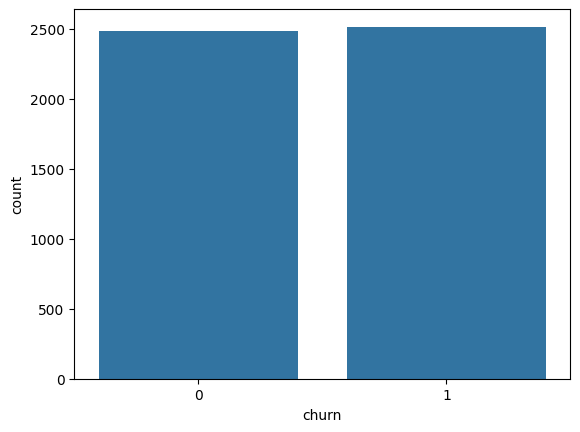

In [21]:
sns.countplot(data=df, x="churn")

## Análise Inicial do Churn

A análise inicial da variável `churn` mostrou uma taxa de cancelamento de aproximadamente 50,30%.

Esse valor indica um nível elevado de evasão de clientes, sugerindo possíveis problemas relacionados ao engajamento, retenção ou experiência dos usuários na plataforma.

Além disso, os boxplots das variáveis numéricas indicaram alguns padrões importantes relacionados ao cancelamento das assinaturas. Usuários com mais de 30 dias sem realizar login apresentaram maior tendência ao churn, assim como clientes com baixo percentual médio de consumo diário da plataforma.

Esses comportamentos sugerem que a falta de uso e o baixo engajamento podem estar fortemente associados ao cancelamento das assinaturas.

Dessa forma, torna-se importante investigar quais outros fatores podem estar relacionados ao churn dos clientes.

## Tipo de Assinatura
- Qual tipo de assinatura possui maior taxa de churn?
- Planos com anúncios apresentam maior cancelamento?
- Usuários de planos premium permanecem mais tempo na plataforma?

<Figure size 1600x600 with 0 Axes>

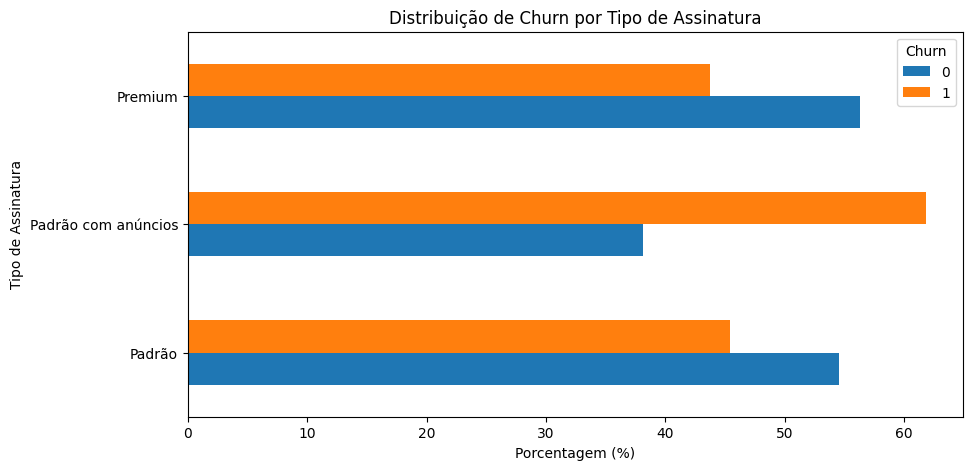

In [25]:
plt.figure(figsize=(16,6))

tabela = pd.crosstab(
    df["tipo_assinatura"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por Tipo de Assinatura")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Tipo de Assinatura")
plt.legend(title="Churn")

plt.show()

## Horas Assistidas
- Clientes com menos horas assistidas cancelam mais?
- Usuários mais engajados apresentam menor churn?
- Existe relação entre tempo de uso e retenção?

<Figure size 1600x600 with 0 Axes>

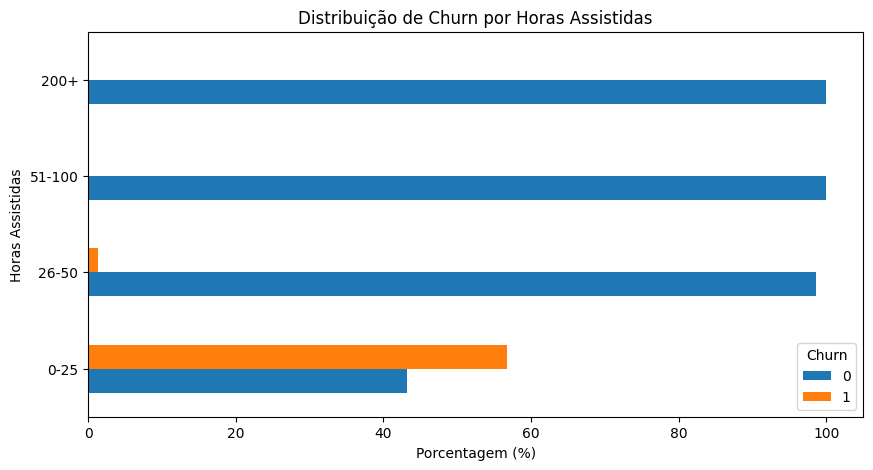

In [26]:
bins = [0, 25, 50, 100, 200]
labels = [
    "0-25",
    "26-50",
    "51-100",
    "200+"
]

df["horas_faixa"] = pd.cut(
    df["horas_assistidas"],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(16,6))

tabela = pd.crosstab(
    df["horas_faixa"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por Horas Assistidas")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Horas Assistidas")
plt.legend(title="Churn")

plt.show()

In [27]:
df["horas_faixa"].value_counts()

horas_faixa
0-25      4417
26-50      500
51-100      81
200+         2
Name: count, dtype: int64

Usuários com maior quantidade de horas assistidas apresentaram menor tendência ao churn. Entretanto, as faixas acima de 50 horas possuem uma quantidade reduzida de usuários, o que limita conclusões definitivas sobre esses grupos específicos.

## Último Dia Logado
- Ficar muitos dias sem acessar a plataforma aumenta o churn?
- Existe um período crítico de desengajamento antes do cancelamento?

<Figure size 1600x600 with 0 Axes>

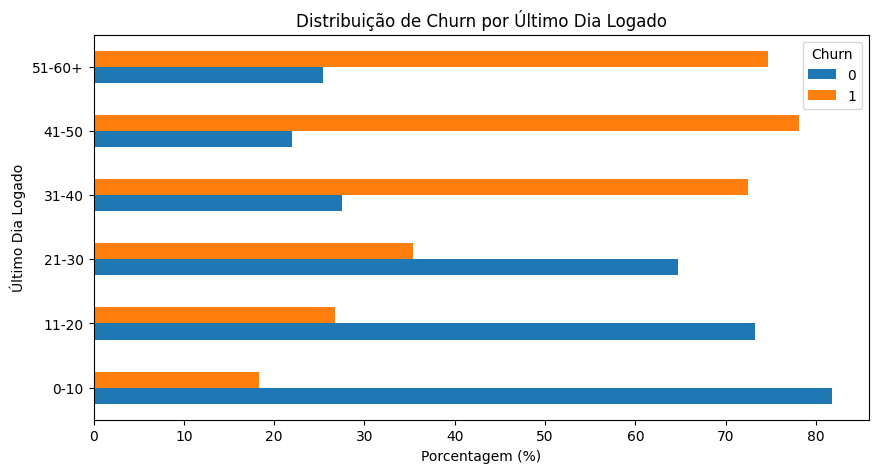

In [28]:
bins = [0, 10, 20, 30, 40, 50, 60]
labels = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60+"
]

df["ult_dia_login"] = pd.cut(
    df["ultimo_dia_logado"],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(16,6))

tabela = pd.crosstab(
    df["ult_dia_login"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por Último Dia Logado")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Último Dia Logado")
plt.legend(title="Churn")

plt.show()

Pela análise dos dados, foi possível observar que usuários que ficaram mais de 30 dias sem acessar a plataforma apresentaram uma taxa de churn significativamente maior em comparação com aqueles que acessaram mais recentemente.

## Dispositivo
- O dispositivo utilizado influencia no churn?
- Usuários mobile cancelam mais que usuários de TV ou computador?

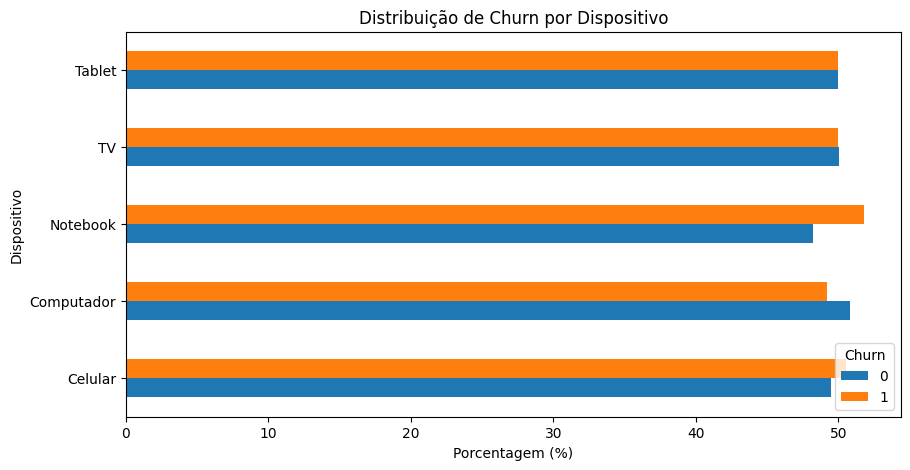

In [30]:
tabela = pd.crosstab(
    df["dispositivo"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por Dispositivo")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Dispositivo")
plt.legend(title="Churn")

plt.show()

Usuarios que acessam a plataforma principalmente por dispositivos móveis apresentaram uma taxa de churn mais elevada em comparação com aqueles que utilizam TV ou computador. Isso pode estar relacionado a fatores como a experiência de uso, limitações de tela ou preferências de consumo.

## Pagamento Mensal
- Assinaturas mais caras apresentam maior retenção?
- Usuários de planos mais baratos cancelam mais?

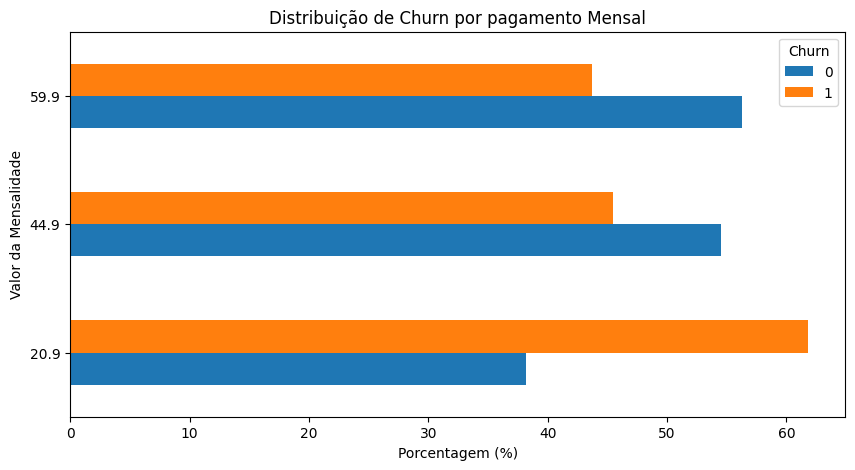

In [31]:
tabela = pd.crosstab(
    df["pagamento_mensal"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por pagamento Mensal")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Valor da Mensalidade")
plt.legend(title="Churn")

plt.show()

Mesmo sendo a mais barata entre as opções de assinatura, a assinatura de R$ 20,90 apresentou uma taxa mais elevada de churn possivelmente por ser uma assinatura contendo anúncios, o que pode impactar negativamente a experiência do usuário e levar ao cancelamento da assinatura.

## Método de Pagamento
- Métodos de pagamento automáticos possuem menor churn?
- Usuários que utilizam gift card ou criptomoedas apresentam maior cancelamento?

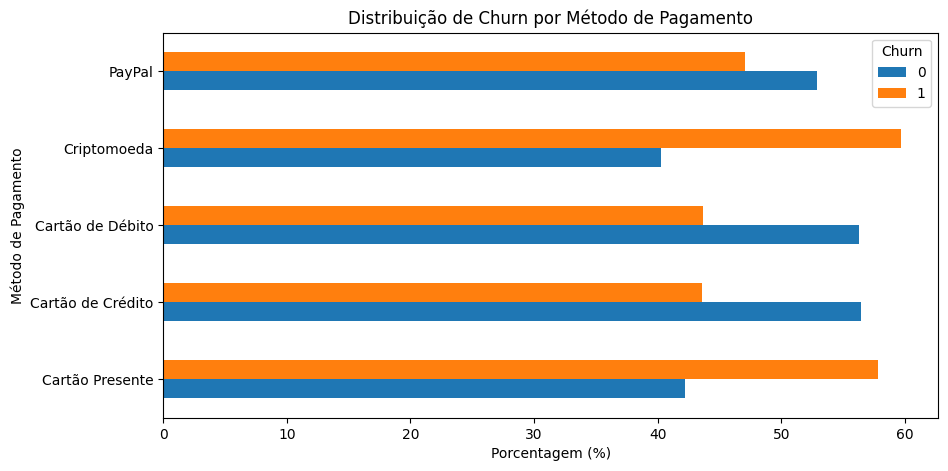

In [32]:
tabela = pd.crosstab(
    df["metodo_pagamento"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por Método de Pagamento")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Método de Pagamento")
plt.legend(title="Churn")

plt.show()

Usuários que pagam suas assinaturas utilizando métodos automáticos, como cartão de crédito ou débito, apresentaram uma taxa de churn mais baixa em comparação com aqueles que utilizam métodos manuais, como gift card ou criptomoedas. Isso pode estar relacionado à conveniência e facilidade de renovação automática, reduzindo a probabilidade de esquecimento ou atraso no pagamento, fatores que podem contribuir para o cancelamento da assinatura.

## Quantidade de Perfis
- Contas com mais perfis possuem menor churn?
- Compartilhamento de conta influencia na retenção?

<Figure size 1600x600 with 0 Axes>

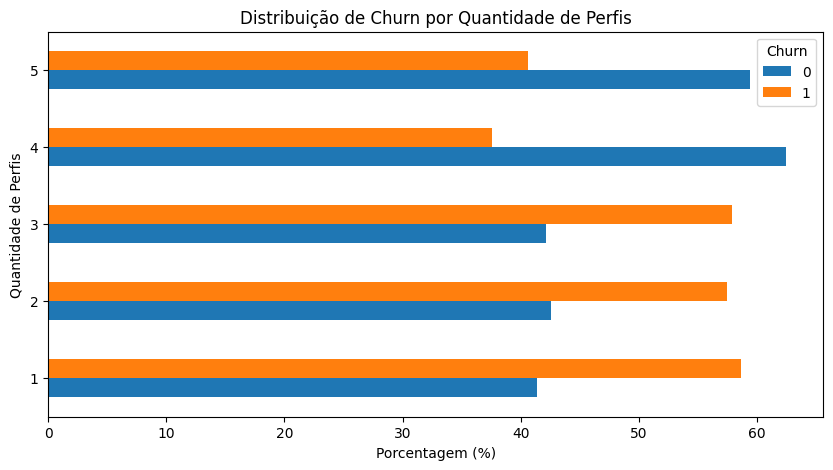

In [33]:
plt.figure(figsize=(16,6))

tabela = pd.crosstab(
    df["quantidade_perfis"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por Quantidade de Perfis")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Quantidade de Perfis")
plt.legend(title="Churn")

plt.show()

A análise da variável `quantidade_perfis` mostrou uma relação relevante entre o número de perfis na conta e o churn.

Contas com apenas 1 ou 2 perfis apresentaram maiores taxas de cancelamento, enquanto contas com 4 ou 5 perfis demonstraram maior retenção e menor tendência ao churn.

Esses resultados sugerem que o compartilhamento de conta pode influenciar positivamente na permanência dos usuários na plataforma. Quanto mais pessoas utilizam a mesma assinatura, maior tende a ser o valor percebido do serviço, reduzindo a probabilidade de cancelamento.

Além disso, contas com múltiplos perfis provavelmente possuem maior frequência de uso e maior diversidade de consumo de conteúdo, fatores que também podem contribuir para o aumento da retenção.

## Porcentagem Assistida por Dia
- Usuários com menor consumo diário cancelam mais?
- Maior engajamento diário reduz o churn?


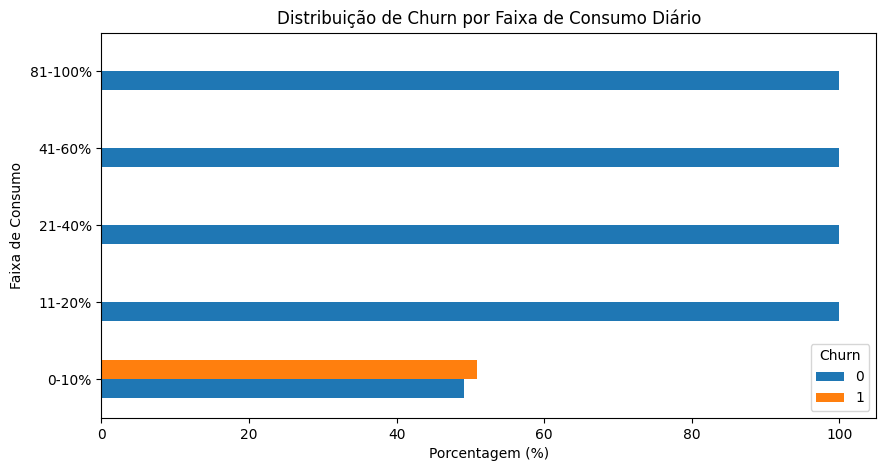

In [34]:
bins = [0, 10, 20, 40, 60, 80, 100]

labels = [
    "0-10%",
    "11-20%",
    "21-40%",
    "41-60%",
    "61-80%",
    "81-100%"
]

df["faixa_consumo"] = pd.cut(
    df["porcentagem_assistida_por_dia"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

tabela = pd.crosstab(
    df["faixa_consumo"],
    df["churn"],
    normalize="index"
) * 100

tabela.plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Distribuição de Churn por Faixa de Consumo Diário")
plt.xlabel("Porcentagem (%)")
plt.ylabel("Faixa de Consumo")
plt.legend(title="Churn")

plt.show()

A análise da variável `porcentagem_assistida_por_dia` indicou uma forte relação entre engajamento e churn.

Usuários com baixo consumo diário da plataforma, especialmente na faixa de 0% a 10%, apresentaram maior taxa de cancelamento em comparação aos demais grupos.

Por outro lado, usuários com níveis mais elevados de consumo diário demonstraram comportamento significativamente mais estável, apresentando taxas muito menores de churn.

Esses resultados reforçam a hipótese de que o engajamento dos usuários possui forte influência na retenção da plataforma, indicando que clientes que utilizam mais o serviço tendem a perceber maior valor na assinatura e, consequentemente, cancelar menos.

---

# Análise Bivariada

Nesta etapa serão analisadas as relações entre diferentes variáveis do dataset, com o objetivo de identificar padrões de comportamento e possíveis fatores que influenciam o engajamento e a retenção dos usuários.

As análises bivariadas permitem compreender como determinadas características podem estar conectadas entre si, auxiliando na interpretação dos fatores relacionados ao churn.



## Quantidade de Perfis × Horas Assistidas
- Contas com mais perfis apresentam maior tempo de consumo?
- O compartilhamento de conta aumenta o engajamento da plataforma?

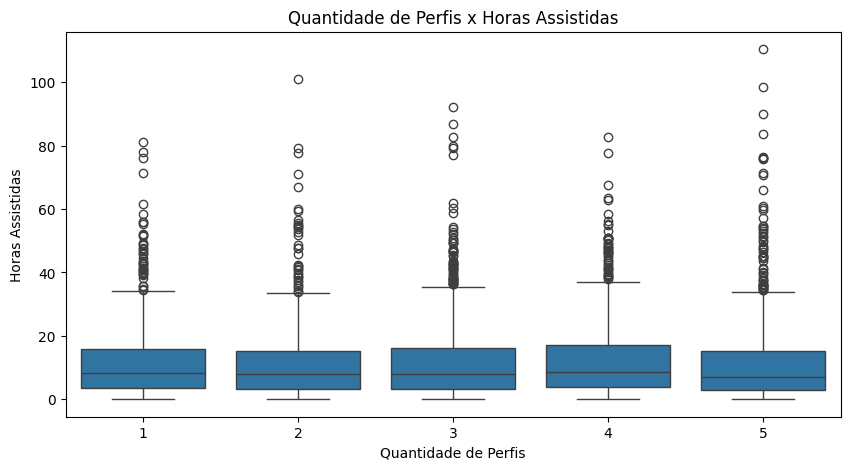

In [38]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="quantidade_perfis",
    y="horas_assistidas"
)

plt.title("Quantidade de Perfis x Horas Assistidas")
plt.xlabel("Quantidade de Perfis")
plt.ylabel("Horas Assistidas")

plt.show()


## Horas Assistidas × Último Dia Logado
- Usuários que ficam muitos dias sem acessar a plataforma assistem menos conteúdo?
- O desengajamento pode ser identificado antes do churn?

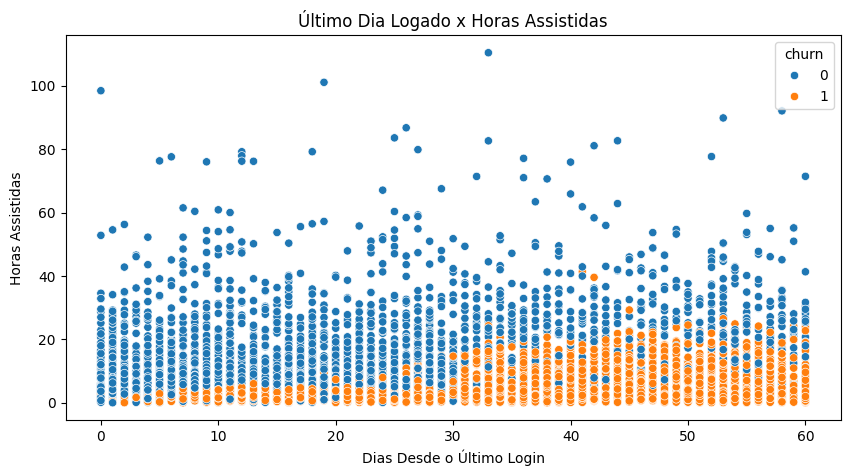

In [39]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="ultimo_dia_logado",
    y="horas_assistidas",
    hue="churn"
)

plt.title("Último Dia Logado x Horas Assistidas")
plt.xlabel("Dias Desde o Último Login")
plt.ylabel("Horas Assistidas")

plt.show()


## Tipo de Assinatura × Horas Assistidas
- Usuários de planos premium apresentam maior consumo?
- Planos com anúncios reduzem o tempo de uso da plataforma?

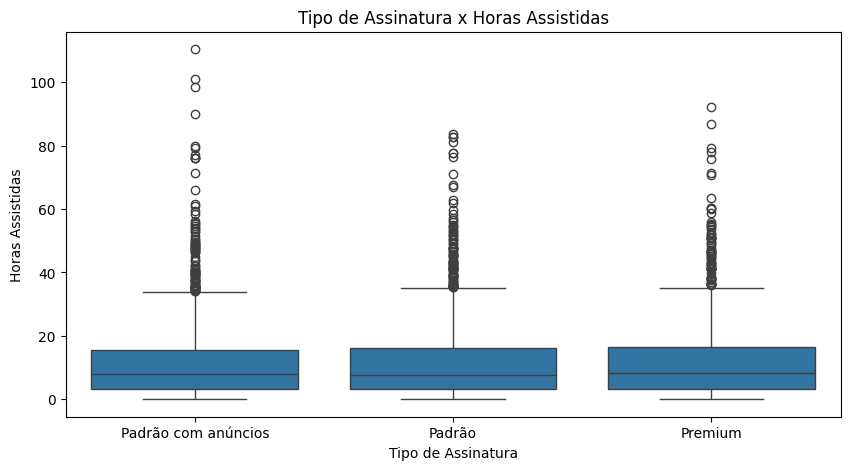

In [40]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="tipo_assinatura",
    y="horas_assistidas"
)

plt.title("Tipo de Assinatura x Horas Assistidas")
plt.xlabel("Tipo de Assinatura")
plt.ylabel("Horas Assistidas")

plt.show()

In [42]:
df.groupby("tipo_assinatura")["horas_assistidas"].mean()

tipo_assinatura
Padrão                11.68
Padrão com anúncios   11.56
Premium               11.71
Name: horas_assistidas, dtype: float64

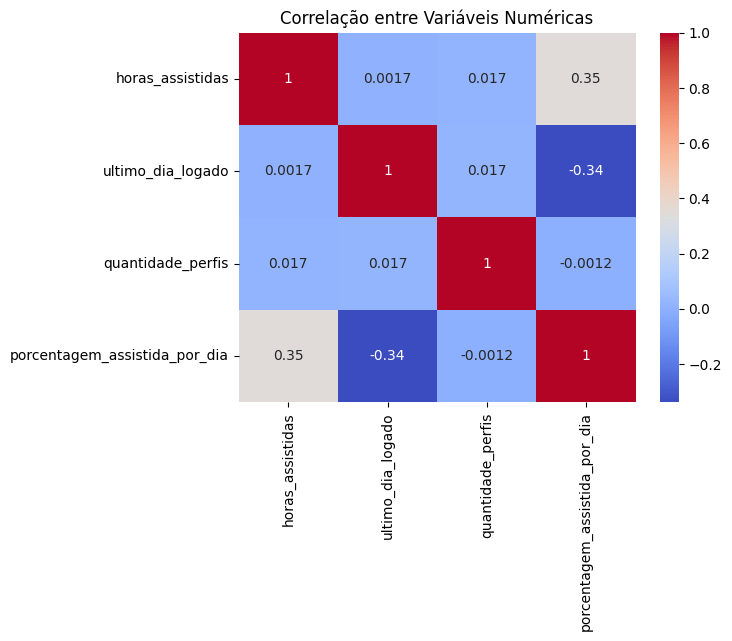

In [41]:
correlacao = df[
    [
        "horas_assistidas",
        "ultimo_dia_logado",
        "quantidade_perfis",
        "porcentagem_assistida_por_dia"
    ]
].corr()

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlação entre Variáveis Numéricas")

plt.show()

## Conclusões da Análise Bivariada

A análise bivariada permitiu identificar relações importantes entre engajamento, comportamento de uso e retenção dos usuários da plataforma.

### Quantidade de Perfis × Horas Assistidas

Os resultados mostraram que contas com maior quantidade de perfis tendem a apresentar uma distribuição ligeiramente maior de horas assistidas. Entretanto, a correlação linear entre essas variáveis foi baixa, indicando que o número de perfis sozinho não explica diretamente o tempo de consumo da plataforma.

Mesmo assim, contas com múltiplos perfis apresentaram menor churn durante análises anteriores, sugerindo que o compartilhamento da assinatura pode contribuir mais para retenção do que necessariamente para aumento significativo do consumo individual.

### Horas Assistidas × Último Dia Logado

Foi possível observar uma relação entre tempo sem acesso e engajamento da plataforma. Usuários com muitos dias sem login tendem a apresentar menores níveis de horas assistidas, principalmente entre clientes com churn.

Além disso, a correlação negativa entre `ultimo_dia_logado` e `porcentagem_assistida_por_dia` reforça a hipótese de que o desengajamento pode ser identificado antes do cancelamento da assinatura.

Esse comportamento fortalece a ideia de que a falta de uso é um dos principais fatores associados ao churn no dataset analisado.

### Tipo de Assinatura × Horas Assistidas

As médias de horas assistidas entre os diferentes tipos de assinatura apresentaram valores muito próximos, indicando que o plano contratado aparentemente não influencia de forma significativa o tempo total de consumo da plataforma.

Apesar disso, análises anteriores mostraram que planos com anúncios possuem maior taxa de churn, sugerindo que a experiência do usuário pode impactar mais a retenção do que o tempo de uso em si.

### Correlação entre Variáveis Numéricas

A matriz de correlação indicou que:

- `horas_assistidas` possui correlação positiva moderada com `porcentagem_assistida_por_dia`;
- `ultimo_dia_logado` possui correlação negativa moderada com `porcentagem_assistida_por_dia`;
- `quantidade_perfis` apresentou correlação muito baixa com as demais variáveis numéricas.

Esses resultados reforçam que métricas relacionadas ao engajamento e frequência de uso aparentam possuir maior influência sobre o comportamento de churn dos usuários.


---

# Conclusão Final

A análise exploratória permitiu identificar padrões importantes relacionados ao comportamento dos usuários e aos fatores associados ao churn da plataforma.

Os resultados indicaram que o engajamento dos usuários aparenta ser o principal fator relacionado à retenção. Clientes com baixo percentual de consumo diário, poucas horas assistidas e muitos dias sem realizar login apresentaram maior tendência ao cancelamento da assinatura.

Além disso, outros fatores também demonstraram possível influência no churn, como:
- planos com anúncios;
- métodos de pagamento não recorrentes;
- contas com menor quantidade de perfis;
- determinados padrões de consumo de conteúdo.

Durante as análises, foi possível observar que usuários mais engajados tendem a permanecer na plataforma por mais tempo, reforçando a importância da experiência de uso e da frequência de consumo para retenção dos clientes.

---

## Possíveis Ações para Redução do Churn

Com base nos resultados obtidos, algumas estratégias que poderiam auxiliar na redução do churn seriam:

- melhorar o sistema de recomendação de conteúdo para aumentar o engajamento dos usuários;
- criar campanhas direcionadas para clientes com muitos dias sem login;
- incentivar métodos de pagamento recorrentes e automáticos;
- oferecer benefícios para contas familiares ou com múltiplos perfis;
- reduzir o impacto negativo de anúncios na experiência dos usuários;
- desenvolver estratégias de retenção para usuários com baixo consumo da plataforma.

---

## Considerações Finais

Este projeto teve como objetivo praticar etapas fundamentais da análise de dados, incluindo:
- limpeza e tratamento de dados;
- padronização das informações;
- análise exploratória;
- visualização de dados;
- interpretação de padrões e comportamentos.

Através da análise realizada, foi possível transformar dados em insights relevantes sobre retenção e comportamento dos usuários em uma plataforma de streaming.

---